# How is the SequenceMatrix paper being cited?

A first look at the citation corpus we assembled for
[issue #127](https://github.com/gaurav/taxondna/issues/127). The anchor paper is
**Vaidya, Lohman & Meier (2011),** *"SequenceMatrix: concatenation software for
the fast assembly of multi-gene datasets with character set and codon
information"*, *Cladistics* 27(2): 171–180
([doi:10.1111/j.1096-0031.2010.00329.x](https://doi.org/10.1111/j.1096-0031.2010.00329.x),
OpenAlex `W2131473084`).

This notebook is the **read-only, show-the-numbers** companion to the data
pipeline. It loads the flat table the pipeline produced and renders:

1. a breakdown of the corpus by publication type,
2. a bar chart of citations per year since publication,
3. the top-10 journals and top-10 authors,
4. the most common two-word phrases in the citing-paper titles.

All of the collection and methodology lives in
[`citations/README.md`](README.md); this notebook only *reads* the cached
output, so running it never touches a network API.

## Where the data came from

We are looking at **every citing work OpenAlex knows about — not just the recent
ones.** The pull uses the filter `cites:W2131473084` and walks the full
cursor-paginated result set, so the corpus spans **2010–2026 (2,509 works)**, the
entire 15-year life of the paper. That is about **84% of the 2,986 citations
Google Scholar reports**; the ~480-paper gap is the long tail of theses,
proceedings, and regional journals OpenAlex does not index. For trend analysis
that recall is fine — see the discussion in
[`README.md`](README.md#anchor-record).

The numbers below come from a small, idempotent pipeline (each script caches its
upstream responses to disk, so re-runs are cheap and offline):

| Step | Script | What it does |
| --- | --- | --- |
| 1 | [`scripts/fetch_openalex_citing.py`](scripts/fetch_openalex_citing.py) | Pull every citing work from the OpenAlex API into `data/openalex/raw/page_*.json` |
| 2 | [`scripts/build_citing_works.py`](scripts/build_citing_works.py) | Flatten the raw pages into one record per paper → `data/openalex/citing_works.jsonl` |
| 3 | [`scripts/analyze_phase2.py`](scripts/analyze_phase2.py) | Derive the analysis table **`data/openalex/citing_works.csv`** (this notebook's input) and the [`phase2_metadata.md`](phase2_metadata.md) digest |

Two further steps enrich the picture but are **not used by this notebook**:
[`scripts/extract_cz_comentions.py`](scripts/extract_cz_comentions.py) cross-checks
the [CZ Software Mentions](https://doi.org/10.5061/dryad.6wwpzgn2c) corpus, and
[`scripts/build_fulltext_coverage.py`](scripts/build_fulltext_coverage.py) measures
how much of the corpus is reachable as free full text
(→ [`data/fulltext/coverage.csv`](data/fulltext/coverage.csv)). Each data
subdirectory has its own `README.md` documenting schema, license, and source
citations.

To reproduce from scratch: `cd citations && cp .env.example .env` (add a free
OpenAlex key), `uv sync`, then run steps 1–3 in order.

## Load the analysis table

`citing_works.csv` is one row per citing paper. Multi-valued columns
(`author_names`, `institution_names`, `topic_displays`, `software_comentions`, …)
are `; `-joined strings, which we split on demand. We only need a handful of
columns here.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve paths relative to this notebook so it runs from anywhere.
HERE = Path.cwd()
CSV = HERE / "data" / "openalex" / "citing_works.csv"
assert CSV.exists(), f"Run the pipeline first; missing {CSV}"

PAPER_YEAR = 2011  # SequenceMatrix was published in Cladistics in 2011.

df = pd.read_csv(CSV)
df["publication_year"] = pd.to_numeric(df["publication_year"], errors="coerce").astype("Int64")

print(f"{len(df):,} citing works, {df['publication_year'].min()}–{df['publication_year'].max()}")
df[["publication_year", "title", "venue_name", "is_oa"]].head()

2,509 citing works, 2010–2026


,publication_year,title,venue_name,is_oa
0,2019,PhyloSuite: An integrated and scalable desktop...,Molecular Ecology Resources,True
1,2013,The Tree of Life and a New Classification of B...,PLoS Currents,True
2,2014,FASconCAT-G: extensive functions for multiple ...,Frontiers in Zoology,True
3,2015,Combining phylogenomic and supermatrix approac...,Molecular Phylogenetics and Evolution,False
4,2012,Macroevolutionary Dynamics and Historical Biog...,PLoS ONE,True


## What kind of works cite SequenceMatrix?

Before the trends, a sanity check on the *shape* of the corpus. OpenAlex tags
each work with a `type` from its
[work-type vocabulary](https://docs.openalex.org/api-entities/works/work-object#type)
(`article`, `preprint`, `dissertation`, …). The corpus is overwhelmingly
**peer-reviewed journal articles** — the audience the proposal cares about — with
a tail of preprints, theses, and reviews. (`peer-review` here is OpenAlex's label
for standalone peer-review reports, not a quality flag on the articles.)

In [2]:
by_type = (
    df["type"]
    .fillna("(unknown)")
    .value_counts()
    .rename_axis("Publication type")
    .reset_index(name="Works")
)
by_type["% of corpus"] = (100 * by_type["Works"] / by_type["Works"].sum()).round(1)
by_type.index += 1
by_type

,Publication type,Works,% of corpus
1,article,2264,90.2
2,preprint,112,4.5
3,peer-review,68,2.7
4,dissertation,38,1.5
5,review,13,0.5
6,letter,4,0.2
7,dataset,3,0.1
8,book-chapter,2,0.1
9,paratext,2,0.1
10,retraction,1,0.0


## Citations per year since publication

The headline number for the proposal: usage is **steady at ~250–300 citations a
year, with no decline 15 years after publication.** 2026 is partial (the pull was
2026-05-24) and is drawn in a lighter shade so nobody reads the dip as a trend.

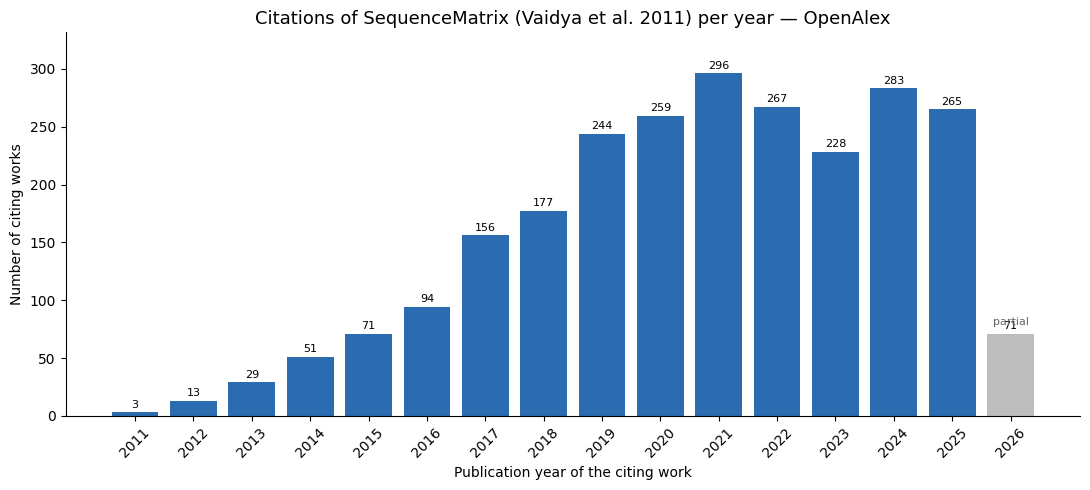

Total since 2011: 2,507 citing works
Mean over all complete years 2011–2025: 162/yr
Mean over the last 5 complete years 2021–2025: 268/yr  (no decline 15 years on)


In [3]:
per_year = (
    df["publication_year"]
    .dropna()
    .loc[lambda s: s >= PAPER_YEAR]   # 2 stray 2010 "early view" records pre-date publication
    .value_counts()
    .sort_index()
)

CURRENT_YEAR = int(per_year.index.max())  # 2026 — partial year, fetched mid-May
colors = ["#bdbdbd" if y == CURRENT_YEAR else "#2b6cb0" for y in per_year.index]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(per_year.index.astype(int), per_year.values, color=colors)
ax.bar_label(bars, padding=2, fontsize=8)

ax.set_title("Citations of SequenceMatrix (Vaidya et al. 2011) per year — OpenAlex", fontsize=13)
ax.set_xlabel("Publication year of the citing work")
ax.set_ylabel("Number of citing works")
ax.set_xticks(per_year.index.astype(int))
ax.tick_params(axis="x", rotation=45)
ax.margins(y=0.12)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.text(
    CURRENT_YEAR, per_year.loc[CURRENT_YEAR] + 6,
    "partial", ha="center", va="bottom", fontsize=8, color="#666",
)
fig.tight_layout()
plt.show()

complete = per_year.loc[:CURRENT_YEAR - 1]
recent = complete.loc[CURRENT_YEAR - 5:]  # last 5 complete years — the proposal window
print(f"Total since {PAPER_YEAR}: {int(per_year.sum()):,} citing works")
print(f"Mean over all complete years {PAPER_YEAR}–{CURRENT_YEAR - 1}: {complete.mean():.0f}/yr")
print(f"Mean over the last 5 complete years {CURRENT_YEAR - 5}–{CURRENT_YEAR - 1}: "
      f"{recent.mean():.0f}/yr  (no decline 15 years on)")

## New-taxon papers over time: *sp. nov.* and *gen. nov.*

In taxonomy, ***sp. nov.*** ("species nova") marks a paper that formally describes
a new species; ***gen. nov.*** ("genus novum") marks one that erects a new genus.
Counting how many citing papers carry these terms in their titles tells us what
fraction of SequenceMatrix's user base is actively doing primary taxonomic work —
as opposed to, say, population-level or ecological phylogenetics.

The stacked bars below show paper counts per year:

- **blue (bottom):** papers with *sp. nov.* in the title — the core species-description signal
- **light blue (top):** papers that additionally carry *gen. nov.* — new genera always accompany a new species definition, so they stack on top rather than overlap

2026 is partial and drawn in lighter shades, consistent with the chart above.

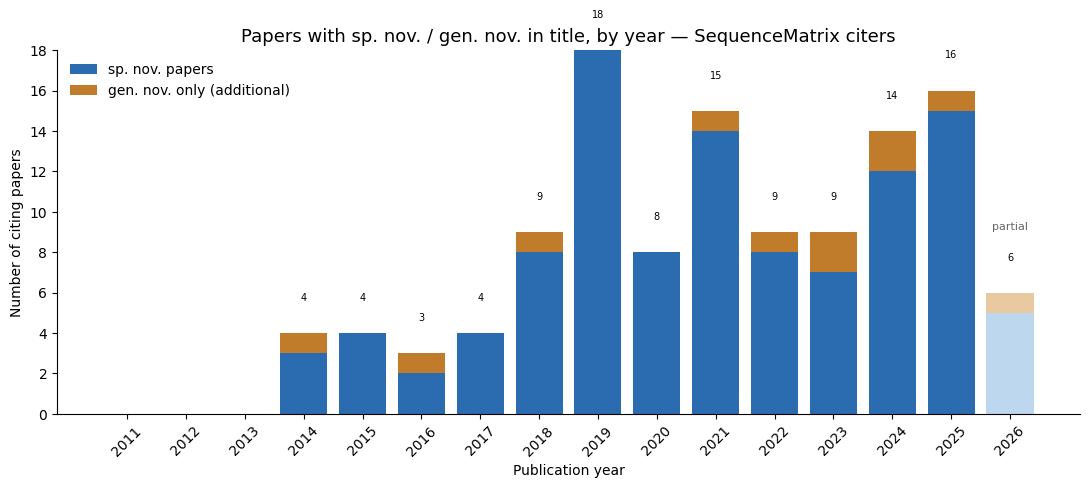

sp. nov. papers (all years):     108
gen. nov. papers (all years):    17
sp. nov. share of corpus:        4.3%
Mean sp. nov. papers/yr (2011–2025): 6.9


In [4]:
import re

def has_term(series, term):
    escaped = re.escape(term)
    return series.fillna("").str.contains(escaped, case=False, regex=True)

sp_nov_mask = has_term(df["title"], "sp. nov.")
gen_nov_mask = has_term(df["title"], "gen. nov.")

year_range = range(int(PAPER_YEAR), int(per_year.index.max()) + 1)

sp_by_year  = df.loc[sp_nov_mask,  "publication_year"].value_counts().reindex(year_range, fill_value=0).sort_index()
gen_by_year = df.loc[gen_nov_mask, "publication_year"].value_counts().reindex(year_range, fill_value=0).sort_index()

# gen. nov. almost always co-occurs with sp. nov.; draw only the gen-nov-only increment
# so the two layers truly stack to "papers with at least one of the two terms"
gen_only_by_year = df.loc[gen_nov_mask & ~sp_nov_mask, "publication_year"].value_counts().reindex(year_range, fill_value=0).sort_index()

years = list(year_range)
sp_vals  = sp_by_year.values
gen_vals = gen_only_by_year.values   # stacked on top of sp_nov layer

sp_colors  = ["#bdd7ee" if y == CURRENT_YEAR else "#2b6cb0" for y in years]
gen_colors = ["#e8c9a0" if y == CURRENT_YEAR else "#c07b2b" for y in years]

fig, ax = plt.subplots(figsize=(11, 5))
bars_sp  = ax.bar(years, sp_vals,  color=sp_colors,  label="sp. nov. papers")
bars_gen = ax.bar(years, gen_vals, bottom=sp_vals, color=gen_colors, label="gen. nov. only (additional)")

# Label total height on bars that have any content
for x, s, g in zip(years, sp_vals, gen_vals):
    total = int(s) + int(g)
    if total > 0:
        ax.text(x, total + 1.5, str(total), ha="center", va="bottom", fontsize=7)

ax.set_title("Papers with sp. nov. / gen. nov. in title, by year — SequenceMatrix citers", fontsize=13)
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of citing papers")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)
ax.margins(y=0.12)
ax.legend(frameon=False)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.text(CURRENT_YEAR, sp_vals[years.index(CURRENT_YEAR)] + gen_vals[years.index(CURRENT_YEAR)] + 3,
        "partial", ha="center", va="bottom", fontsize=8, color="#666")
fig.tight_layout()
plt.show()

complete_years = [y for y in years if y < CURRENT_YEAR]
print(f"sp. nov. papers (all years):     {int(sp_by_year.sum()):,}")
print(f"gen. nov. papers (all years):    {int(gen_by_year.sum()):,}")
print(f"sp. nov. share of corpus:        {100 * sp_nov_mask.sum() / len(df):.1f}%")
print(f"Mean sp. nov. papers/yr ({PAPER_YEAR}–{CURRENT_YEAR-1}): "
      f"{sp_by_year.loc[sp_by_year.index < CURRENT_YEAR].mean():.1f}")

## Top 10 journals and top 10 authors

**Journals** are counted one row per paper. **Authors** are counted once per paper
they appear on — so the leaders are people who repeatedly publish multi-gene
phylogenies, the bread-and-butter SequenceMatrix workflow.

In [5]:
def split_multi(series):
    """Explode a "; "-joined column into one tidy value per row, dropping blanks."""
    return (
        series.dropna()
        .str.split(";")
        .explode()
        .str.strip()
        .loc[lambda s: s.ne("")]
    )

In [6]:
top_journals = (
    df.loc[df["venue_type"].eq("journal"), "venue_name"]
    .dropna()
    .value_counts()
    .head(10)
    .rename_axis("Journal")
    .reset_index(name="Citing papers")
)
top_journals.index += 1
top_journals

,Journal,Citing papers
1,MycoKeys,118
2,Molecular Phylogenetics and Evolution,101
3,Scientific Reports,69
4,Mitochondrial DNA Part B,66
5,PLoS ONE,58
6,Zoological Journal of the Linnean Society,58
7,Systematic Entomology,51
8,Zoologica Scripta,48
9,Journal of Fungi,44
10,Frontiers in Microbiology,36


In [7]:
top_authors = (
    split_multi(df["author_names"])
    .value_counts()
    .head(10)
    .rename_axis("Author")
    .reset_index(name="Citing papers")
)
top_authors.index += 1
top_authors

,Author,Citing papers
1,Kevin D. Hyde,64
2,Qiang Li,40
3,Gonzalo Giribet,30
4,Qi Zhao,30
5,Ruvishika S. Jayawardena,28
6,Zong-Long Luo,28
7,Yong Wang,24
8,Łukasz Michalczyk,24
9,Jian‐Kui Liu,22
10,Yong‐Zhong Lu,22


## Most common two-word phrases in citing-paper titles

A quick qualitative read on *what kind of study* cites SequenceMatrix. Rather
than a word cloud, we count **two-word phrases** in the titles — bigrams carry
the domain signal that single words wash out (*"molecular phylogeny"*,
*"species delimitation"*, *"mitochondrial genome"*). We strip generic
research-paper filler ("new", "study", "analysis", "based", …) and the
taxonomic abbreviations ("sp.", "nov.") so only content phrases remain.

Counts are **document frequency**: the number of distinct citing papers whose
title contains the phrase. We list phrases down to a floor of **10 papers** —
below that the long tail is mostly one-off taxon names, not a usage pattern.
This is impressionistic; the curated topic and software-co-mention breakdowns in
[`phase2_metadata.md`](phase2_metadata.md) are the rigorous version.

The phrases that surface here — *molecular phylogeny, phylogenetic relationships,
species complex, integrative taxonomy, species delimitation* — are the raw
material for the next step: picking a handful of **usage markers** (e.g.
*"phylogenetic analysis"*, *"sp. nov."*, *"gen. nov."*) and plotting them over
time to see which workflows are growing or fading.

In [8]:
import re
from collections import Counter

# Generic research-paper filler plus taxonomic abbreviations ("sp. nov.") that
# would otherwise dominate any biology corpus. A phrase is dropped if *either*
# of its two words is in here.
PHRASE_STOPWORDS = {
    "the", "and", "for", "from", "with", "within", "into", "via", "between",
    "among", "new", "study", "studies", "analysis", "analyses", "based",
    "using", "use", "used", "data", "first", "record", "records", "note",
    "notes", "description", "two", "three", "reveals", "revealed", "insights",
    "evidence", "case", "sp", "nov", "spp", "gen", "approach", "review",
    "results", "their", "this", "that", "these", "those", "its", "are", "was",
    "were", "not", "more", "most", "some", "such", "than", "then", "both",
}

MIN_PAPERS = 10   # drop phrases seen in fewer titles than this — long-tail noise
TOP_N = 50        # cap the table length even if more clear the floor


def title_phrases(titles):
    '''Document frequency of two-word phrases across a column of titles.

    Each phrase is counted at most once per title, so the count reads as
    "number of citing papers" rather than raw occurrences.
    '''
    counts = Counter()
    for title in titles.dropna().astype(str):
        words = re.findall(r"[a-z]+", title.lower())
        seen = set()
        for w1, w2 in zip(words, words[1:]):
            if len(w1) < 3 or len(w2) < 3:
                continue
            if w1 in PHRASE_STOPWORDS or w2 in PHRASE_STOPWORDS:
                continue
            seen.add(f"{w1} {w2}")
        counts.update(seen)
    return counts


phrase_counts = title_phrases(df["title"])

top_phrases = (
    pd.Series(dict(phrase_counts.most_common()))
    .loc[lambda s: s >= MIN_PAPERS]
    .head(TOP_N)
    .rename_axis("Phrase")
    .reset_index(name="Papers")
)
top_phrases.index += 1
print(f"{len(top_phrases)} phrases in ≥10 of "
      f"{df['title'].notna().sum():,} titles (floor {MIN_PAPERS}, cap {TOP_N})")
top_phrases

50 phrases in ≥10 of 2,507 titles (floor 10, cap 50)


,Phrase,Papers
1,mitochondrial genome,163
2,complete mitochondrial,120
3,mitochondrial genomes,84
4,molecular phylogeny,77
5,phylogenetic relationships,65
6,province china,38
7,species complex,36
8,phylogenetic implications,35
9,novel species,31
10,phylogenetic position,29


## Random sample by time band

To ground-truth how SequenceMatrix usage has evolved, we draw two random samples
of citing papers stratified by time:

| Band | Years | Sample size |
| --- | --- | --- |
| `recent` | 2025–2026 | 10 |
| `earlier` | up to 2024 | 10 |

The sample is written to **`outputs/random-citations-by-timing.csv`** (relative to the
`citations/` directory) for manual review. Add your own columns there — the file
is intentionally sparse so it stays easy to fill in by hand.

A fixed random seed (`RANDOM_SEED = 42`) makes the draw reproducible; re-running
the pipeline with the same data produces the same 20 rows.

In [9]:
import os

RANDOM_SEED = 42
SAMPLE_N = 10

recent_mask = df["publication_year"].ge(2025)
earlier_mask = df["publication_year"].le(2024)

sample_recent = df.loc[recent_mask].sample(n=SAMPLE_N, random_state=RANDOM_SEED)
sample_earlier = df.loc[earlier_mask].sample(n=SAMPLE_N, random_state=RANDOM_SEED)

sample_recent = sample_recent.assign(band="recent (2025–2026)")
sample_earlier = sample_earlier.assign(band="earlier (up to 2024)")

SAMPLE_COLS = [
    "band", "openalex_id", "doi", "title",
    "publication_year", "author_names", "venue_name", "is_oa",
]

sample = pd.concat([sample_recent, sample_earlier])[SAMPLE_COLS].reset_index(drop=True)
sample.index += 1

# Write to citations/random/citations-by-time.csv
out_dir = HERE / "outputs"
out_dir.mkdir(exist_ok=True)
out_csv = out_dir / "random-citations-by-timing.csv"
sample.to_csv(out_csv, index=False)
print(f"Wrote {len(sample)} rows → {out_csv}")

sample

Wrote 20 rows → /Users/gaurav/Developer/taxondna/citations/outputs/random-citations-by-timing.csv


,band,openalex_id,doi,title,publication_year,author_names,venue_name,is_oa
1,recent (2025–2026),https://openalex.org/W4407029908,https://doi.org/10.3897/mycokeys.113.142643,Morpho-phylogenetic evidence reveals Pseudolom...,2025,Jing-Yi Zhang; Kevin D. Hyde; Jian Ma; Na Wu; ...,MycoKeys,True
2,recent (2025–2026),https://openalex.org/W7133508878,https://doi.org/10.1371/journal.pone.0340630,Structural and phylogenetic insights from comp...,2026,Mohammad Mehdi Golchini; Aboozar Soorni,PLoS ONE,True
3,recent (2025–2026),https://openalex.org/W7134239287,https://doi.org/10.1002/nzb2.70065,<i>Lasiobelonium sublanceolatum</i> sp. nov. (...,2026,Hong‐Li Su; Thilini Chethana Kandawatte Wedara...,New Zealand Journal of Botany,False
4,recent (2025–2026),https://openalex.org/W7123579634,https://doi.org/10.3389/fmicb.2025.1677230,Glutamate potentiates susceptibility of P. aer...,2026,Wedad M. Nageeb; ‏Helal F. Hetta; Dan Frampton...,Frontiers in Microbiology,True
5,recent (2025–2026),https://openalex.org/W7125681960,https://doi.org/10.3897/mycokeys.127.180874,Two new species of Periconia and a new record ...,2026,Lijuan Zhang; Hong-xiu LIU; Yan-Ling Yang; Xin...,MycoKeys,True
6,recent (2025–2026),https://openalex.org/W7126053148,https://doi.org/10.3897/mycokeys.127.173937,"Two new Neohelicomyces species (Tubeufiaceae, ...",2026,MEI-YAN HAN; Jing-Ya Yang; SC Karunarathna; Ja...,MycoKeys,True
7,recent (2025–2026),https://openalex.org/W4414328373,https://doi.org/10.3897/mycokeys.122.164540,Morphological and multi-gene phylogenetic anal...,2025,Wangming Zhang; Xiaoyu Song; Wanqing Xie; Xin-...,MycoKeys,True
8,recent (2025–2026),https://openalex.org/W7127583237,https://doi.org/10.1098/rspb.2025.2149,Tracing the origins of Antarctic periwinkles: ...,2026,Sebastián Rosenfeld; Claudia S. Maturana; Mois...,Proceedings of the Royal Society B Biological ...,True
9,recent (2025–2026),https://openalex.org/W7140214411,https://doi.org/10.3390/jof12040231,Natural Selection Drives AT-Biased Codon Usage...,2026,Yanan Cao; Xianli Guo; Jialin Yang; Xiyue Yan;...,Journal of Fungi,True
10,recent (2025–2026),https://openalex.org/W4411782738,https://doi.org/10.1093/isd/ixaf020,"Phylogeny, molecular species delimitation, and...",2025,Dongming Wang; Chris H. Dietrich; Qingquan Xue...,Insect Systematics and Diversity,False


## Where to go next

This notebook covers the metadata-only picture (Phases 1–2). The repo also has:

- **Usage markers over time** — the immediate next step: track a curated set of
  title/abstract phrases (*"phylogenetic analysis"*, *"sp. nov."*, *"gen. nov."*,
  …) year by year to see which SequenceMatrix workflows are growing or fading.
- **Full-text coverage** — 69% of the corpus is reachable for free
  ([`data/fulltext/coverage.csv`](data/fulltext/coverage.csv)); see Phase 3a in
  [`README.md`](README.md#phase-3a-results-full-text-coverage-table-done-2026-05-25).
- **Software co-mentions** — which tools appear alongside SequenceMatrix in the
  same papers (`software_comentions` column here; CZ cross-check in
  [`data/cz_software_mentions/`](data/cz_software_mentions/README.md)).
- **Planned LLM extraction** (Phase 4) of *how* each paper actually used the
  tool — see the phased plan in [`README.md`](README.md#phased-plan).